# Target-Reaching Study

# Check which Python

In [69]:
# Check which kernel 
import sys 

# Check python version 
print(sys.version)
# Check which executable 
print()
print(sys.executable)
# And what is in the path
print()
print(sys.path) 

3.9.23 (main, Jun  5 2025, 08:49:36) 
[Clang 14.0.6 ]

/Users/guirecdetournemire/miniconda3/envs/simulation/bin/python3.9

['/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python39.zip', '/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9', '/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/lib-dynload', '', '/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/site-packages']


In [70]:
# sys.path.insert(0, '/path/to/other/env/lib/python3.9/site-packages')

# Importations

In [71]:
import numpy as np

import sys
import time
from tqdm import tqdm
import copy
from scipy.io import savemat, loadmat

from scipy.optimize import curve_fit

from multiprocessing import Pool

from numba import njit

In [72]:
from simulations.langevin.DoubleWalls_Overdamped_Langevin import DoubleWallsLangevin

In [73]:
import simulations.langevin.ComputeObservables as co

In [74]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpltools import annotation
from matplotlib import rc
import seaborn as sns
# custom_params = {
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "lines.markeredgecolor": "k",
#     "lines.markeredgewidth": 0.3,
#     "lines.linewidth": 1.5, 
#     "xtick.direction": "in",
#     "xtick.labelsize": 9,
#     "ytick.direction": "in",
#     "ytick.labelsize": 9, 
#     "font.size": 9, 
#     "font.family": "serif",
#     "figure.dpi": 500,
#     "text.usetex": True,
# }
# sns.set_theme(context = "notebook", style="ticks", rc=custom_params)
rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.3)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)
rc('font', family='serif', size=9)
rc('text', usetex=True)
rc('figure', dpi=500)
rc('savefig', dpi=500)

BlueUB = (0, 157/255, 224/255)
BrownUB = (68/255, 58/255, 49/255)

# Auxiliary Functions 

In [75]:
def compute_lB(a, drho, kT=4e-21, g=9.81):
    return kT / (4/3*np.pi*a**3*drho*g)

In [76]:
# Here z is the gap between the particle and the (bottom) wall

def diffusing_diffusivity_z(z, a):
    res = (6*(z**2) + 2*a*z) / (6*(z**2) + 9*a*z + 2*(a**2))
    return res

def diffusing_diffusivity_x(z, a):
    ksi = a / (a + z)
    res = (1 - (9/16)*(ksi) + (1/8)*(ksi**3) - (45/256)*(ksi**4) + (1/16)*(ksi**5))
    return res

In [77]:
def _P_eq(z, B, lD, lB):
    return np.exp(-B * np.exp(-z / lD) - z / lB)

def P_eq(z, B, lD, lB, normalize=True):
    if type(z) == float:
        if z < 0:
            res = 0
        return _P_eq(z, B, lD, lB)
    res = _P_eq(z, B, lD, lB)
    res[z < 0] = 0
    if normalize:
        res = res / np.trapz(res, z) # Ok because it is a change of variable
    return res

In [78]:
def Levy(t, L, D, x0=0):
    res = abs(L - x0) / np.sqrt(4*np.pi*D*t**3) * np.exp(-(L - x0)**2 / (4*D*t)) 
    return res

def Levy_confined(t, L, z0, D, lB):    
    res = (((L - z0 + (D/lB)*t))/(np.sqrt(4*np.pi*D*(t**3))))  *   np.exp(-(L-(z0 - (D/lB)*t))**2/(4*D*t))
    return res

In [79]:
def logarithmic_hist(data, begin, stop, num=50, base=2, density=True):
    if begin == 0:
        beg = stop / num
        bins = np.logspace(
            np.log(beg) / np.log(base), 
            np.log(stop) / np.log(base), 
            num - 1, 
            base=base, 
        )
        widths = bins[1:] - bins[:-1]
        bins = np.cumsum(widths[::-1])
        bins = np.concatenate(([0], bins))
        widths = bins[1:] - bins[:-1]
    else:
        bins = np.logspace(
            np.log(begin) / np.log(base), 
            np.log(stop) / np.log(base), 
            num, 
            base=base, 
            dtype=np.float64, 
        )
        widths = bins[1:] - bins[:-1]
    hist, bins = np.histogram(data, bins=bins, density=density)
    # hist = hist / np.trapezoid(hist, bins)
    # normalize by bin width
    bins_center = (bins[1:] + bins[:-1]) / 2
    return bins_center, widths, hist

### load a experimental data.mat to copy parameters

In [12]:
data_exp_path = '/Users/guirecdetournemire/Desktop/PhD/data/2023/20230824/confined2/data_exp_PS_exp_20230824_analysis_20250919_filename_traj_rp_2p9706_np_1p5896_vid_2_ratioBC_None.mat'
data_exp = loadmat(data_exp_path, squeeze_me = True)

In [13]:
a = data_exp['r']
z = data_exp['z_dedrift']
lD = data_exp['fitted_lD']
lB = data_exp['fitted_lB']
B = data_exp['fitted_B']

In [14]:
z_to_integrate = np.linspace(1e-9, 15e-6, 1000)
gamma_perp = np.trapezoid(P_eq(z=z_to_integrate, B=B, lD=lD, lB=lB, normalize=True)/diffusing_diffusivity_z(z=z_to_integrate, a=a) , z_to_integrate)
gamma_para = np.trapezoid(P_eq(z=z_to_integrate, B=B, lD=lD, lB=lB, normalize=True)/diffusing_diffusivity_x(z=z_to_integrate, a=a) , z_to_integrate)

/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_1436/3066425789.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res = res / np.trapz(res, z) # Ok because it is a change of variable


In [15]:
a

2.9706e-06

In [16]:
print( "D_para_from gamma theory : " + str(1/gamma_para))
print( "D_para_from experiment : " + str(data_exp['mean_D_para_from_MSD']))

D_para_from gamma theory : 0.47862487024350225
D_para_from experiment : 0.4072174109155231


In [17]:
print( "D_perp from gamma theory : " + str(1/gamma_perp))
print( "D_perp from experiment : " + str(data_exp['mean_D_perp_from_MSD']))

D_perp from gamma theory : 0.04139880290182043
D_perp from experiment : 0.057161983966988496


# Global variables

In [80]:
kb = 1.38e-23
T = 293
kT = kb * T
g = 9.81
print(kT)

4.0434e-21


In [563]:
# Parameters

H = 50e-6

a = 1.5e-6

H -= a # to be checked again

rho_m = 1000

rho_p = 1050
drho = rho_p - rho_m

lB = compute_lB(a = a, drho = drho)
#lB = 100_000e-9
print('Boltzmann length = {} nm'.format(lB * 1e9))

lD = 35e-9
B = 4.5
print("B = {}".format(B))
print('Debye length = {} nm'.format(lD * 1e9))

eta0 = 0.00095

dt_num = 1e-3
Nt = 1_000_000
Nt_sub = 1
dt = dt_num * Nt_sub
print('Physical timestep = {} s'.format(dt))

Boltzmann length = 576.8442834908427 nm
B = 4.5
Debye length = 35.0 nm
Physical timestep = 0.001 s


# One trajectory

## Simulation of the trajectory

In [564]:
%%time

# Simulation 
# tc_0 = time.time() 
brown = DoubleWallsLangevin(
    dt=dt_num, Nt=Nt, Nt_sub=Nt_sub, 
    a=a, H=H, lD=lD, lB=lB, B=B, eta0=eta0, T=T, 
    R0=None, #(0,-H + a + lB),
)
brown.trajectory() #Compute trajectory of "brown"
# print("Compute time = ", time.time()-tc_0)

CPU times: user 9.47 s, sys: 32.2 ms, total: 9.5 s
Wall time: 9.58 s


In [565]:
x = brown.Xn
z = brown.Zn + H
tps = np.arange(len(z)) * dt

In [566]:
#x = x[900_000:]
#z = z[900_000:]
#tps = np.arange(len(z)) * dt

In [567]:
x

array([ 0.00000000e+00, -8.29093068e-09,  1.15187085e-08, ...,
        1.10124244e-05,  1.10088237e-05,  1.10031314e-05])

In [568]:
save = {}

save['x'] = np.copy(x)
save['z'] = np.copy(z)

save['a'] = a
save['H'] = H
save['B'] = B
save['lD'] = lD
save['lB'] = lB
save['rho_m'] = rho_m
save['rho_p'] = rho_p
save['drho'] = drho
save['eta0'] = eta0
save['kT'] = kT

save['Nt'] = Nt 
save['dt'] = dt
save['dt_num'] = dt_num
save['Nt_sub'] = Nt_sub

## Look at the trajectory and observables

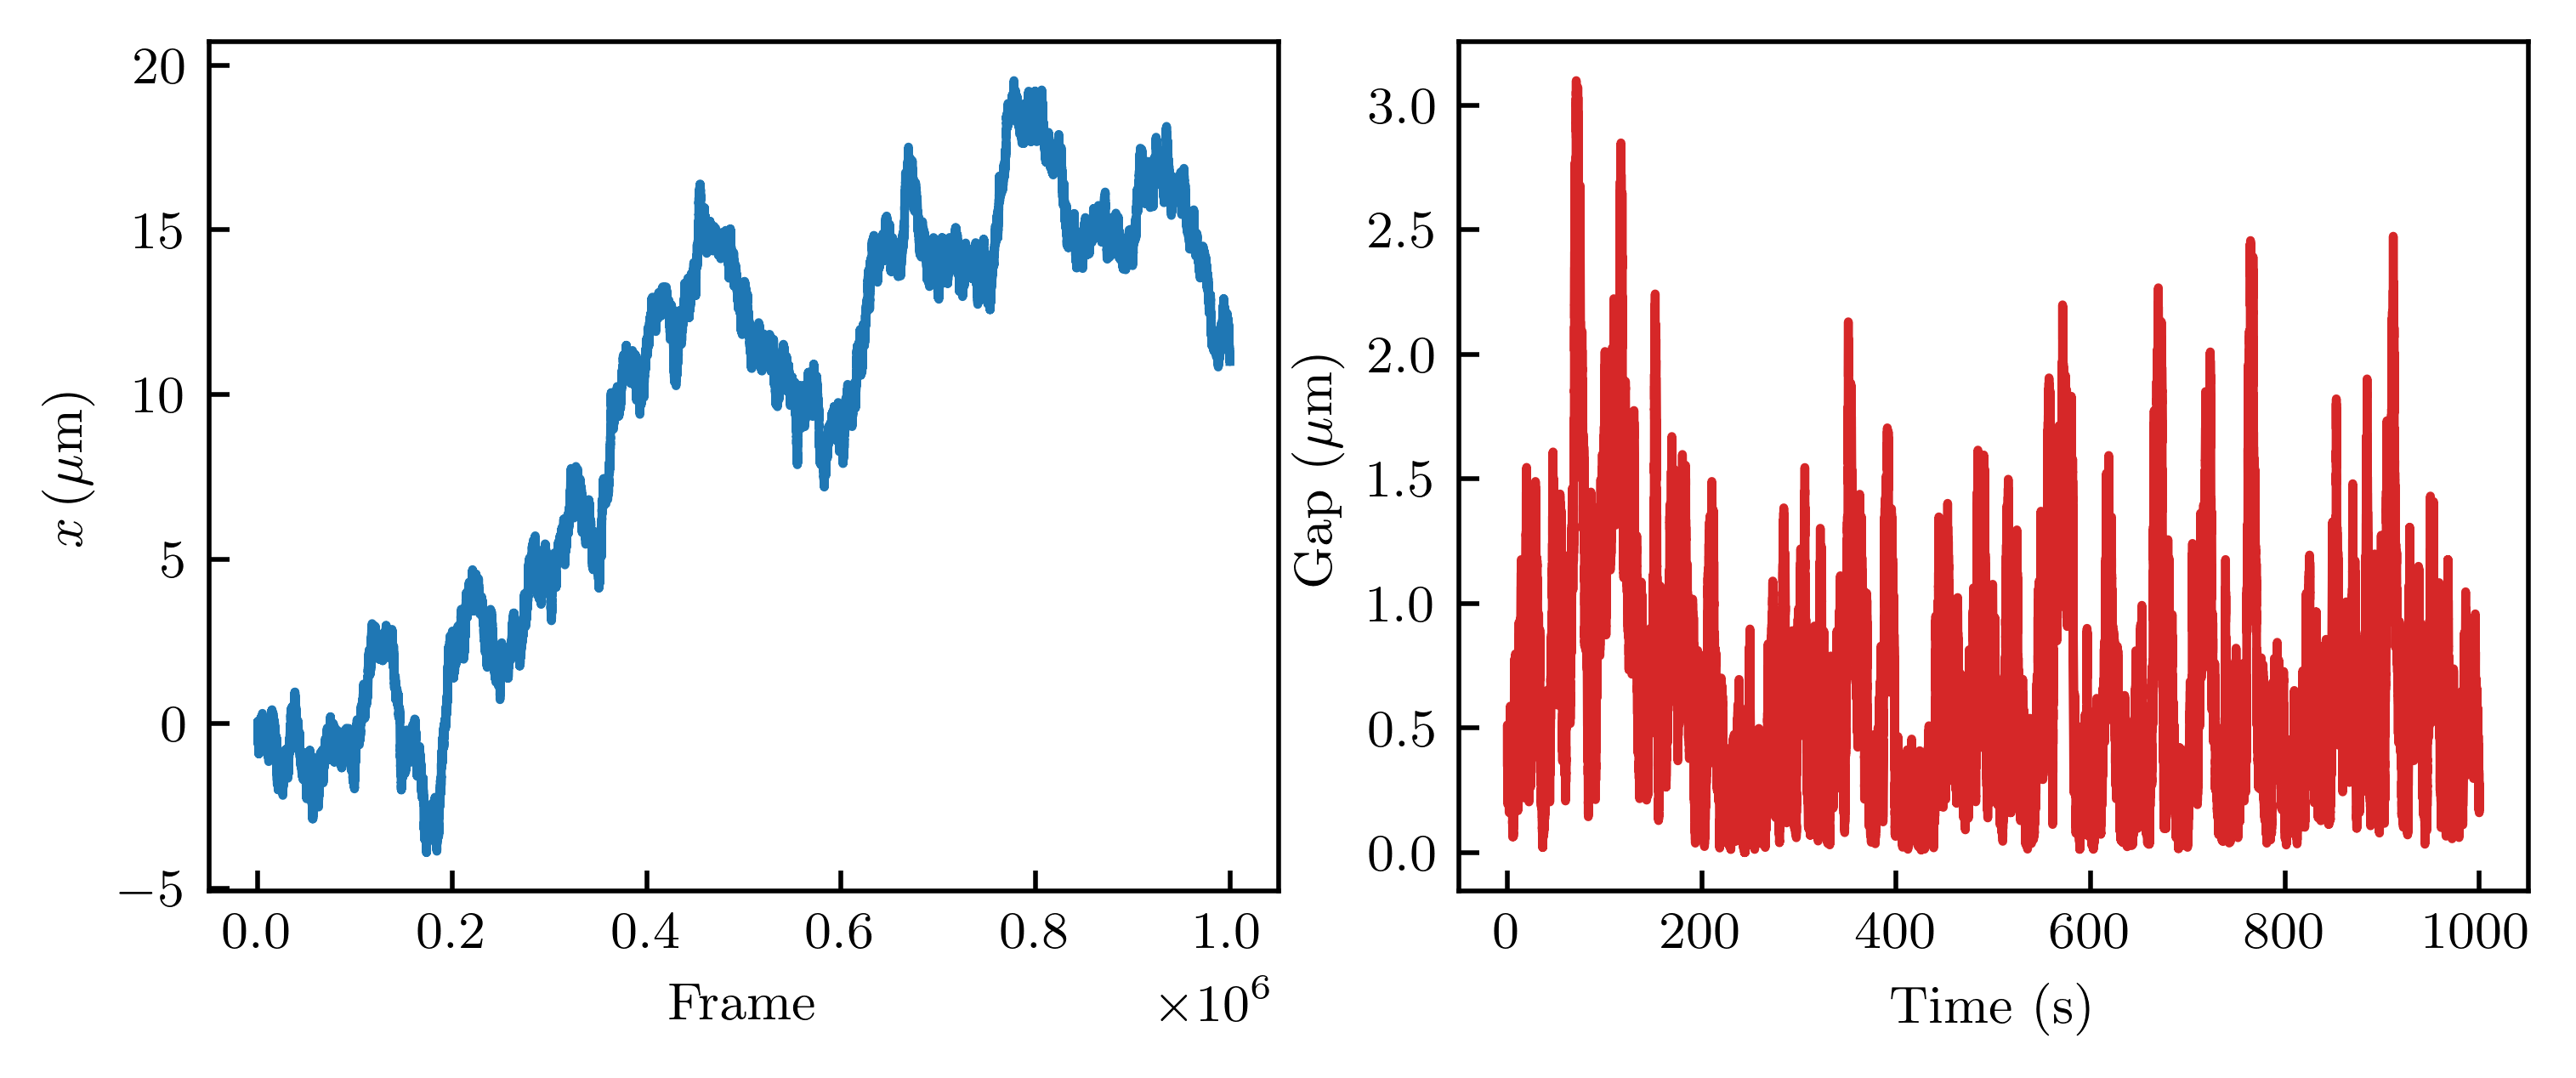

In [569]:
fig, axes = plt.subplots(1, 2, figsize=(15/2.54, 6/2.54))

axes[0].plot(x*1e6, color = 'tab:blue')
axes[0].set(xlabel='Frame', ylabel=r'$x \, (\mathrm{\mu m})$')
axes[1].plot(tps, z*1e6, color = 'tab:red')
axes[1].set(xlabel='Time (s)', ylabel=r'Gap $(\mathrm{\mu m})$')

plt.tight_layout(pad=0.1)
plt.show()
# fig.savefig('traj.pdf')

In [570]:
# fig.savefig('traj.pdf')

In [571]:
# Compute MSDs

delta_frame_nb = np.concatenate(
    (
        np.arange(1, 10, 1),
        np.arange(10, 100, 10),
        np.arange(100, 1000, 100),
        np.arange(1000, 10000, 1000),
        np.arange(10000, 100000, 10000),
    )
)

delta_time_MSD = tps[delta_frame_nb]

MSD_x, std_MSD_x = co.moment(2, x, delta_frame_nb, return_std = True, retrieve_mean = True) # Function in wrapper
MSD_z, std_MSD_z = co.moment(2, z, delta_frame_nb, return_std = True, retrieve_mean = True)

D0 = kT / (6*np.pi*eta0*a)

start = 0
stop = 10
coef_MSD_x = np.polyfit(delta_time_MSD[start:stop], MSD_x[start:stop], 1)
coef_MSD_z = np.polyfit(delta_time_MSD[start:stop], MSD_z[start:stop], 1)
meanDx_MSD = coef_MSD_x[0] / 2
meanDz_MSD = coef_MSD_z[0] / 2

In [572]:
# save['delta_time_MSD'] = np.copy(delta_time_MSD)
# save['MSD_x'] = np.copy(MSD_x)
# save['MSD_z'] = np.copy(MSD_x)

In [573]:
zz = np.linspace(20e-9, 5e-6, int(1e6))
meanDx = np.trapz(P_eq(zz, B, lD, lB) * diffusing_diffusivity_x(zz, a), zz) * D0
meanDz = np.trapz(P_eq(zz, B, lD, lB) * diffusing_diffusivity_z(zz, a), zz) * D0

def _P_dz_long(dz, B, lD, lB, zz=zz):
    return np.trapz(P_eq(zz, B, lD, lB, normalize=False) * P_eq(zz + dz, B, lD, lB, normalize=False), zz)
def P_dz_long(dzz, B, lD, lB, zz=zz):
    res = np.zeros_like(dzz)
    for i in range(len(res)):
        res[i] = _P_dz_long(dzz[i], B, lD, lB, zz=zz)
    res = res / np.trapz(res, dzz)
    return res
dzz = np.linspace(-10e-6, 10e-6, int(1e3))
plateau_MSDz = np.trapz(dzz ** 2 * P_dz_long(dzz, B, lD, lB), dzz)

/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_3252/3066425789.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res = res / np.trapz(res, z) # Ok because it is a change of variable
/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_3252/3659685458.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  meanDx = np.trapz(P_eq(zz, B, lD, lB) * diffusing_diffusivity_x(zz, a), zz) * D0
/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_3252/3659685458.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  meanDz = np.trapz(P_eq(zz, B, lD, lB) * diffusing_diffusivity_z(zz, a), zz) * D0
/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_3252/3659685458.py:6: DeprecationWarning: `trapz` is

In [574]:
D0

1.505326542450923e-13

In [575]:
meanDx/D0

np.float64(0.5959174443052081)

In [576]:
meanDx_MSD/D0

np.float64(0.5633586717970451)

In [577]:
# Compute Peq

# The error on the PDF and the equilibrium force is estimated by:
# Adding a nanometric noise to the trajectory, several times.

n_noisy = 100 # Number of iterations of the noise-adding procedure
min_distance = 50e-9 
max_distance = 5e-6
n_bins = 30

data_P_eq, data_F_eq = co.PeqFeq(z, n_noisy, min_distance, max_distance, n_bins)
# PeqFeq returns two dictionnaries, containing data corresponding to Peq and Feq

x_P_eq, width_P_eq, y_P_eq, std_y_P_eq, err_y_P_eq = data_P_eq.values()
x_F_eq, width_F_eq, y_F_eq, std_y_F_eq, err_y_F_eq = data_F_eq.values()

del data_P_eq, data_F_eq

/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/site-packages/simulations/langevin/ComputeObservables.py:230: RuntimeWarning: divide by zero encountered in log
  y_F_eq = np.gradient(np.log(y_F_eq), x_F_eq) * 4e-21
/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:1253: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:1269: RuntimeWarning: invalid value encountered in scalar subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/site-packages/simulations/langevin/ComputeObservables.py:248: RuntimeWarning: Mean of empty slice
  y_F_eq = np.nanmean(all_y_F_eq, axis=0)
/Users/guirecdetournemire/miniconda3/envs/simulatio

In [578]:
# save['x_P_eq'] = np.copy(x_P_eq)
# save['y_P_eq'] = np.copy(y_P_eq)
# save['x_F_eq'] = np.copy(x_F_eq)
# save['y_F_eq'] = np.copy(y_F_eq)

/var/folders/kd/g58jbbnn3w5088x5lkdq1bdw0000gn/T/ipykernel_3252/3066425789.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res = res / np.trapz(res, z) # Ok because it is a change of variable


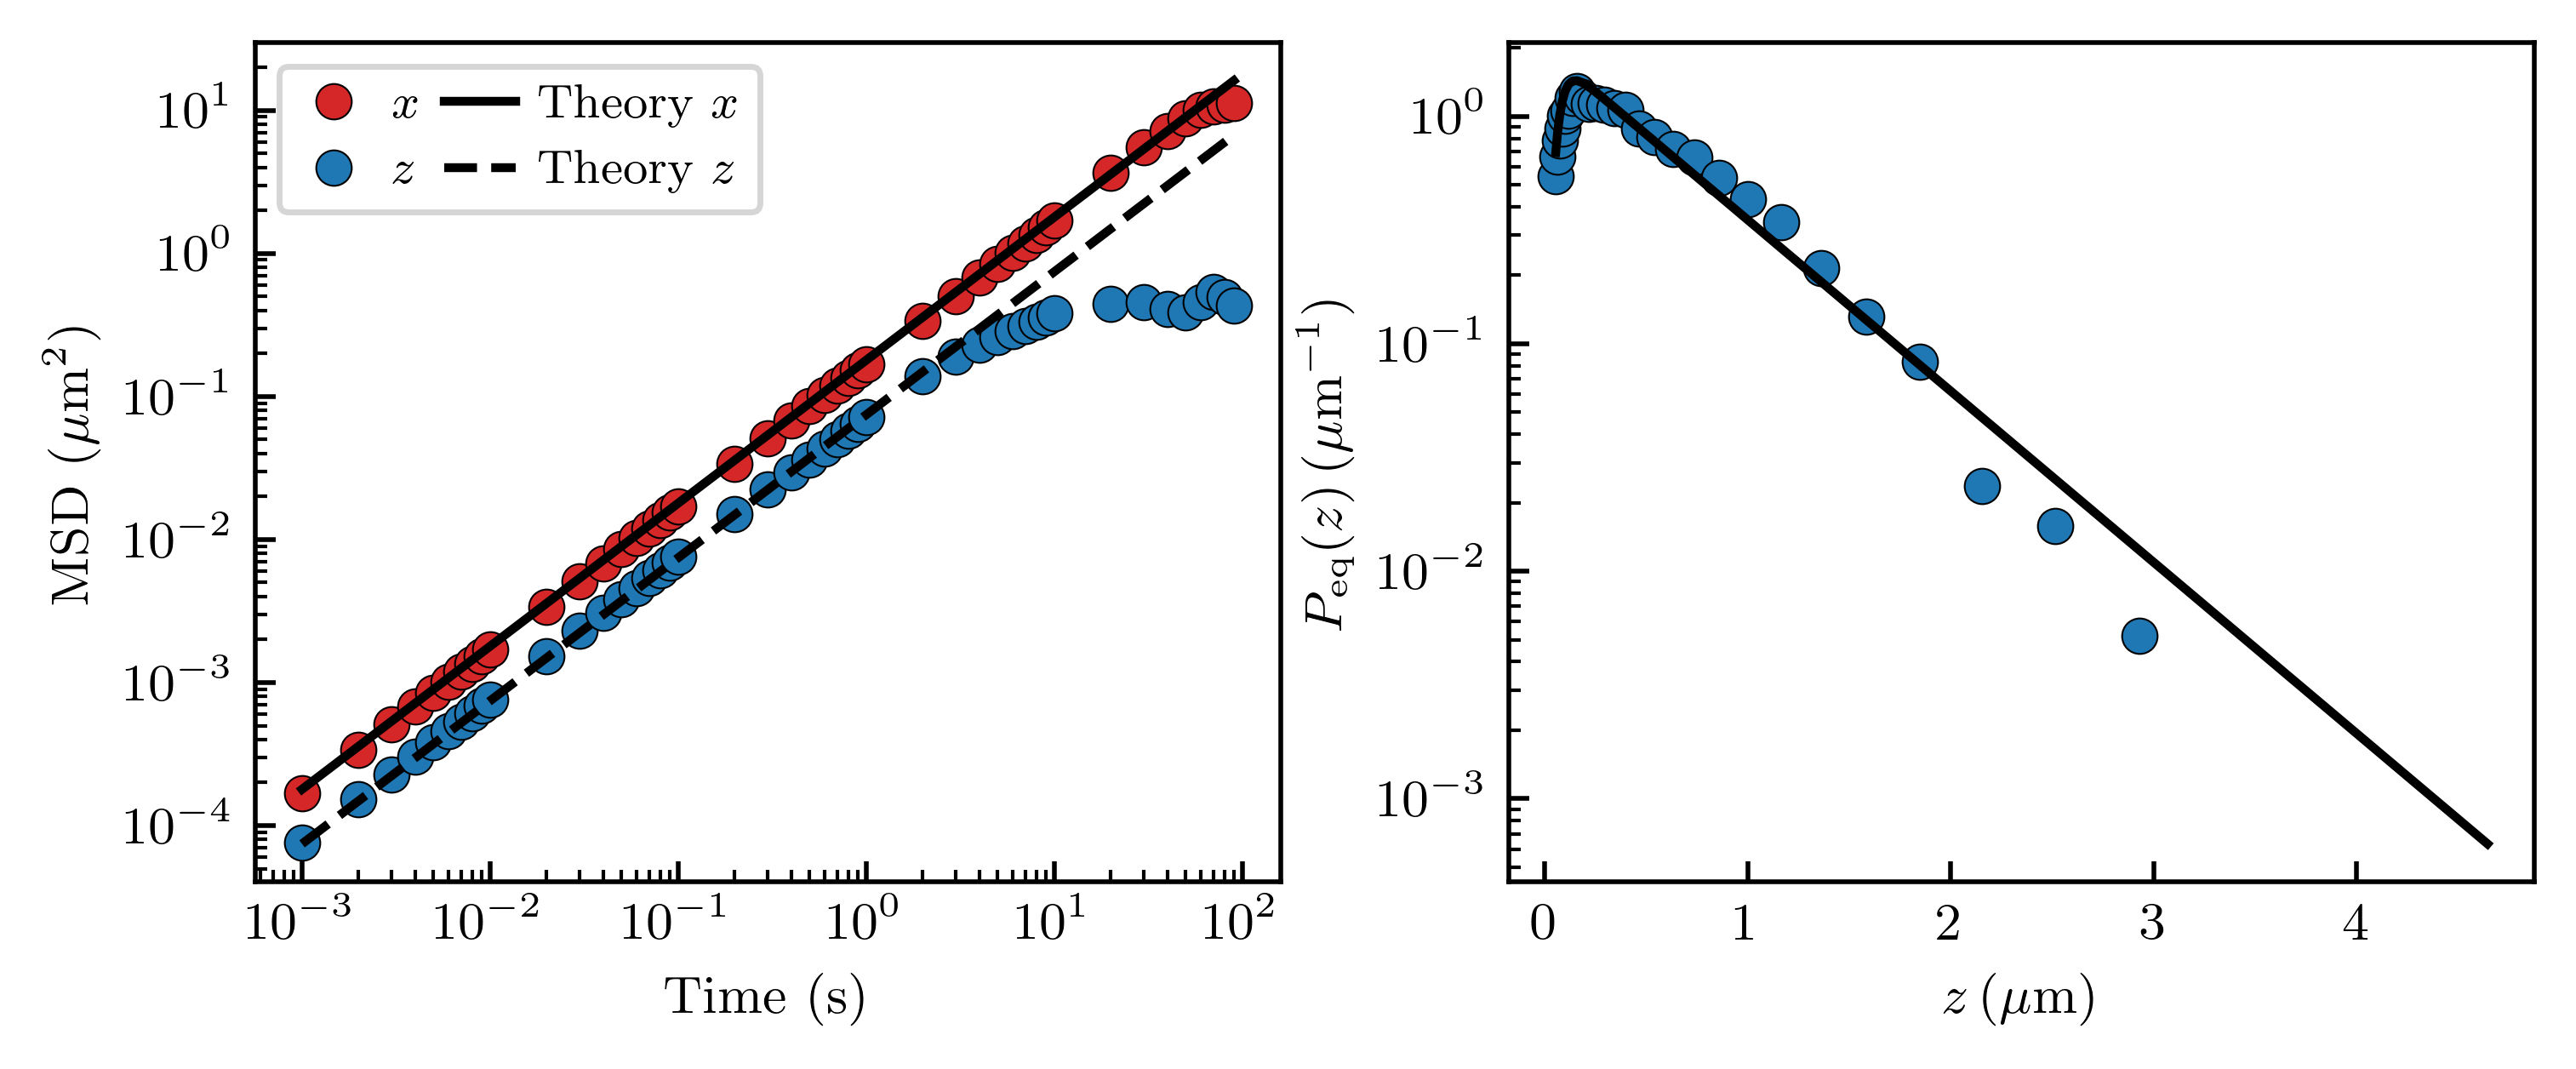

In [579]:
# Plot 

fig, axes = plt.subplots(1, 2, figsize=(15/2.54, 6/2.54))

axes[0].plot(delta_time_MSD, MSD_x*1e12, 'o', mfc='tab:red', label=r'$x$')
axes[0].plot(delta_time_MSD, MSD_z*1e12, 'o', mfc='tab:blue', label=r'$z$')
axes[0].plot(delta_time_MSD, 2 * meanDx * delta_time_MSD * 1e12, ls='-', c='k', label=r'Theory $x$')
axes[0].plot(delta_time_MSD, 2 * meanDz * delta_time_MSD * 1e12, ls='--', c='k', label=r'Theory $z$')
axes[0].legend(frameon=True, handletextpad=0.5, handlelength=1.5, ncol=2, columnspacing=0.5, prop={'size': 8})
axes[0].set(xlabel='Time (s)', ylabel=r'MSD $(\mathrm{\mu m ^2})$', xscale='log', yscale='log')
axes[1].plot(x_P_eq*1e6, y_P_eq*1e-6, 'o', mfc='tab:blue')
axes[1].plot(x_P_eq*1e6, P_eq(x_P_eq, B, lD, lB, normalize=True)*1e-6, ls='-', c='k')
axes[1].set(xlabel=r'$z \, \mathrm{(\mu m)}$', ylabel=r'$P_\mathrm{eq}(z) \, \mathrm{(\mu m ^{-1})}$', xscale='linear', yscale='log')

plt.tight_layout(pad=0.2)
plt.show()

In [580]:
# fig.savefig('first_observables.pdf')

In [581]:
#save_path = '/Users/guirecdetournemire/Desktop/PhD/paper/First Passage Time/data_lB_scan/bulk'
#savemat(save_path + 'traj_simu_bulk.mat', save)

In [582]:
meanDz/D0

np.float64(0.24759413929195107)

In [583]:
meanDz_MSD/D0

np.float64(0.25382205972463767)

## Mean First-Passage Time $t(z)$

In [546]:
z_eq = np.argmax(y_P_eq)
print(z_eq)

5


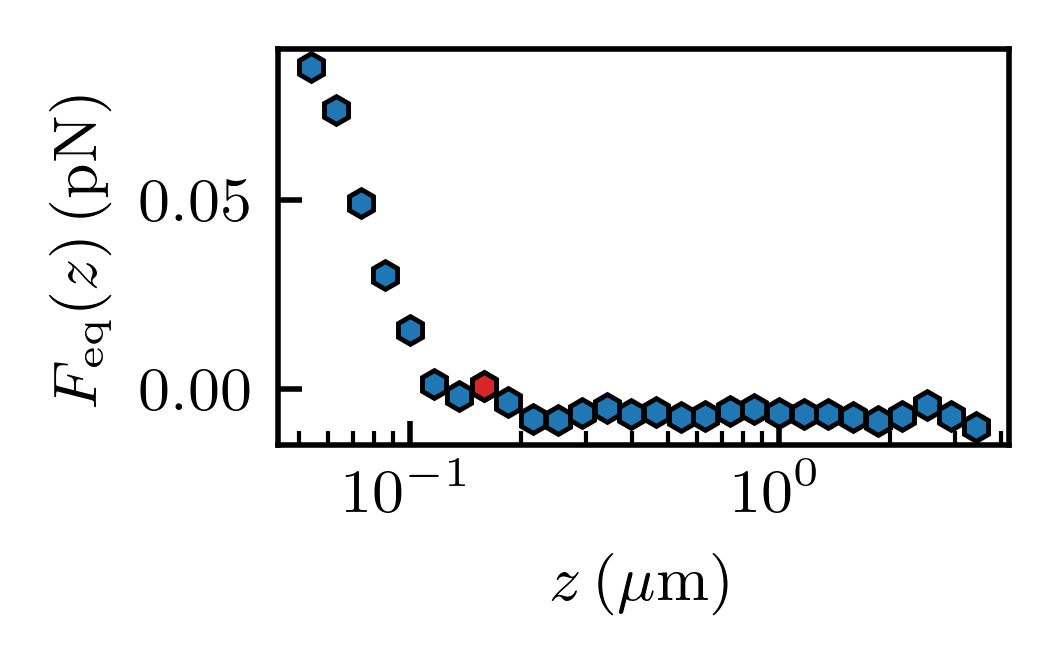

In [547]:
fig, axes = plt.subplots(1, 1, figsize=(5/2.54, 3/2.54))

axes.plot(x_F_eq*1e6, y_F_eq*1e12, 'h',ms = 4, mew = 0.7, mfc='tab:blue')
axes.plot(x_F_eq[7]*1e6, y_F_eq[7]*1e12, 'h',ms = 4, mew = 0.7, mfc='tab:red')

axes.set(xlabel=r'$z \, \mathrm{(\mu m)}$', ylabel=r'$F_\mathrm{eq}(z) \, \mathrm{(pN)}$', xscale='log', yscale='linear')

plt.tight_layout(pad=0.2)
plt.show()

In [44]:
z_eq_min = 0.8e-7
z_eq_max = 1.3e-7

In [45]:
from scipy.stats import linregress

def fit_slope_in_range(x, y, x_min, x_max):
    mask = (x >= x_min) & (x <= x_max)
    x_fit = x[mask]
    y_fit = y[mask]
    slope, intercept, r_value, p_value, std_err = linregress(x_fit, y_fit)
    return slope, intercept, r_value, p_value, std_err
slope = fit_slope_in_range(x_F_eq, y_F_eq, z_eq_min, z_eq_max)[0]
intercept = fit_slope_in_range(x_F_eq, y_F_eq, z_eq_min, z_eq_max)[1]
y_F_eq_fit = slope*x_F_eq + intercept



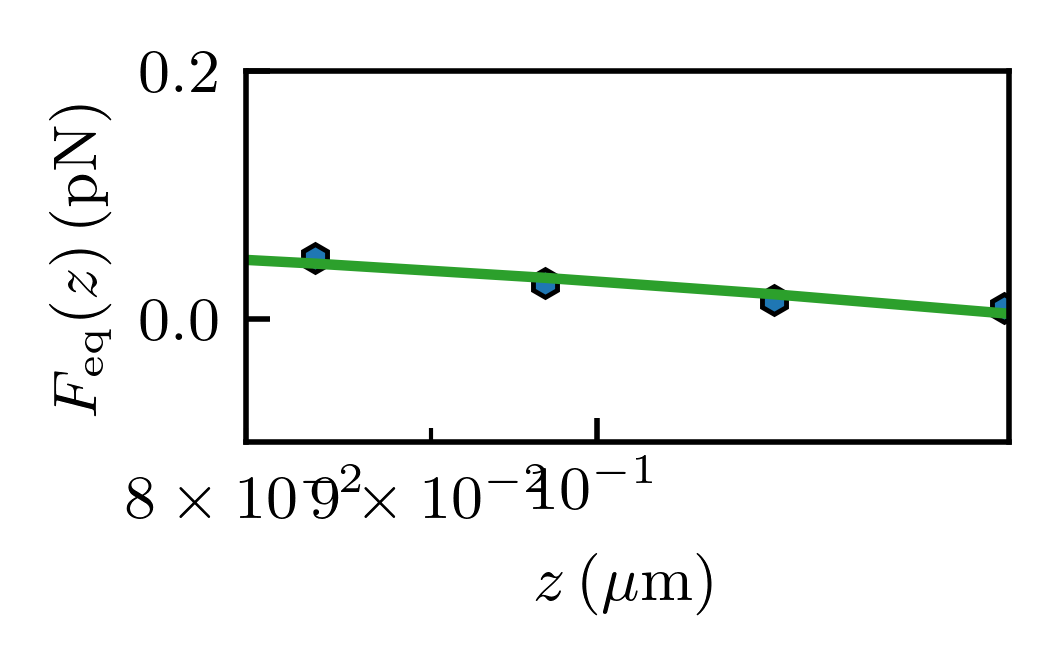

In [46]:
fig, axes = plt.subplots(1, 1, figsize=(5/2.54, 3/2.54))

axes.plot(x_F_eq*1e6, y_F_eq*1e12, 'h',ms = 4, mew = 0.7, mfc='tab:blue')
axes.plot(x_F_eq[7]*1e6, y_F_eq[7]*1e12, 'h',ms = 4, mew = 0.7, mfc='tab:red')
axes.plot(x_F_eq*1e6, y_F_eq_fit*1e12, '-', mfc='tab:blue')
axes.set_ylim(-0.1, 0.2)
axes.set_xlim(0.08, 0.13)

axes.set(xlabel=r'$z \, \mathrm{(\mu m)}$', ylabel=r'$F_\mathrm{eq}(z) \, \mathrm{(pN)}$', xscale='log', yscale='linear')

plt.tight_layout(pad=0.2)
plt.show()

In [47]:
# parameters
k_simu = -slope
z_eq_simu = x_F_eq[7]

In [48]:
z

array([9.69878677e-07, 9.61243685e-07, 9.34582273e-07, ...,
       3.05477845e-07, 3.26681056e-07, 2.95721235e-07])

In [49]:
import numpy as np
from scipy.integrate import quad

def integrand(z, a, D0, k, z_eq):
    kB = 1.38e-6  # constante de Boltzmann adaptée à tes unités
    T = 293       # température en Kelvin
    # fonction à intégrer
    res = (
        np.exp((k/(2*kB*T))*(z_eq**2))
        * (-a/D0)
        * np.sqrt(kB*T*np.pi/(2*k))
        * (1/z)
        * np.exp((k/(kB*T)) * z * (z/2 - z_eq))
    )
    return res

def integral_res(z0, z1, a, D0, k, z_eq):
    """
    Calcule l'intégrale de integrand entre z0 et z1
    """
    val, err = quad(integrand, z0, z1, args=(a, D0, k, z_eq))
    return val

# --- Exemple d'utilisation ---
if __name__ == "__main__":
    a = a
    D0 = D0
    k = k_simu
    z_eq = z_eq_simu
    z0 = min(z)
    z1 = max(z)

    I = integral_res(z0, z1, a, D0, k, z_eq)
    print(f"Intégrale de res entre z0={z0} et z1={z1} : {I:.5e}")


Intégrale de res entre z0=1.2523368755586791e-11 et z1=5.92875602567885e-06 : -3.50885e+09


In [50]:
I = integral_res(z0, z[0], a, D0, k, z_eq)
print(I)

-3022736595.823061


In [51]:
tau = []
zzz = np.linspace(np.min(z), np.max(z), 100)
tau = np.zeros(len(zzz))
for i,L in enumerate(zzz):
    z1 = L
    I = integral_res(z0, z1, a, D0, k, z_eq)
    #print(I)
    tau[i] = integral_res(z0, z1, a, D0, k, z_eq)

[Text(0.5, 0, '$z \\, \\mathrm{(\\mu m)}$'), Text(0, 0.5, '$T$'), None, None]

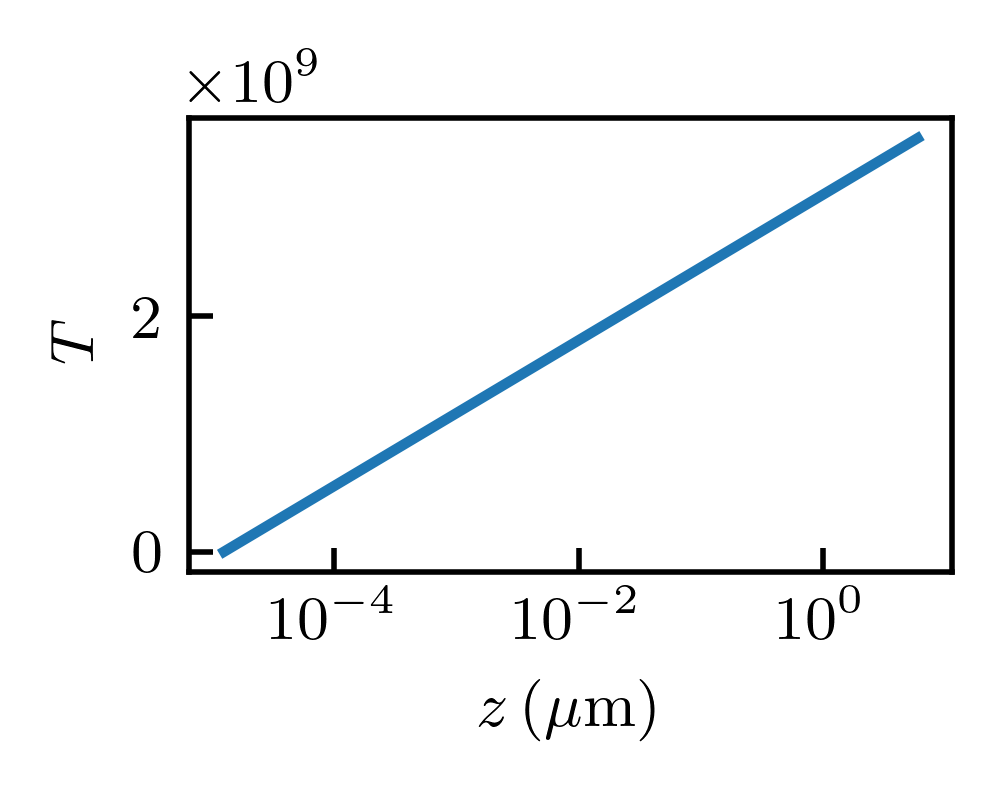

In [52]:
fig, axes = plt.subplots(1, 1, figsize=(5/2.54, 3/2.54))

axes.plot(zzz*1e6, -tau)
axes.set(xlabel=r'$z \, \mathrm{(\mu m)}$', ylabel=r'$T$', xscale='log', yscale='linear')


## First-Passage Time

In [584]:
# Compute FPTs: naive

def get_FPT_naive(x, dt, L):
    Ntot = len(x)
    res = []
    for i in tqdm(range(Ntot)):
        x0 = x[i]
        j = i
        c = 0
        while x[j] < x0 + L:
            j += 1
            c += 1
            if j >= Ntot:
                break
        if j < Ntot:
            res.append(c)
    res = np.array(res)
    res = res * dt
    return res 

In [585]:
%%time 

#FPT_x = get_FPT_naive(x, dt=dt, L=L)

CPU times: user 1 µs, sys: 1e+03 ns, total: 2 µs
Wall time: 3.1 µs


In [586]:
# Compute FPTs: Parallel

# traj = np.copy(x)
# Ntot = len(traj)
# frames = np.arange(Ntot)

def _get_FPT_parallel(traj, Ntot, i, l):
    """
    Returns the time to reach x0+l, starting from one position x0.
    The position x0 corresponds to x[i], with i a time step of the trajectory. 
    """
    x0 = traj[i]
    j = i
    c = 0
    while traj[j] < x0 + l:
        j += 1
        c += 1
        if j >= Ntot:
            break
    if j >= Ntot:
        return np.nan
    res = c * dt 
    return res

def get_FPT_parallel(n_proc, traj, l):
    """
    Returns the distributions of FPTs, for one distance L. 
    Computed over n_proc CPUs.
    """
    Ntot = len(traj)
    frames = np.arange(Ntot)
    with Pool(n_proc) as p:
        res = p.starmap(_get_FPT_parallel, [(traj, Ntot, ff, l) for ff in frames])
    res = np.array(res)
    res = res[~np.isnan(res)]
    return res

# map can be replaced by starmap for more convenient definition of functions to parallelize. 

In [587]:
%%time 

#FPT_x = get_FPT_parallel(4, x, L)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 1.91 µs


In [588]:
# Compute FPTs: Numba

@njit
def get_FPT_numba(x, dt, L):
    Ntot = len(x)
    res = []
    for i in range(Ntot):
        x0 = x[i]
        j = i
        c = 0
        while x[j] < x0 + L:
            j += 1
            c += 1
            if j >= Ntot:
                break
        if j < Ntot:
            res.append(c)
    res = np.array(res)
    res = res * dt
    return res 

### along $x$

In [589]:
L = [300e-9, 500e-9, 700e-9]

In [590]:
%%time

FPT_x_L300nm = get_FPT_numba(x, dt=dt, L=L[0])
FPT_x_L500nm = get_FPT_numba(x, dt=dt, L=L[1])
FPT_x_L700nm = get_FPT_numba(x, dt=dt, L=L[2])

CPU times: user 28 s, sys: 97.7 ms, total: 28.1 s
Wall time: 28.1 s


In [591]:
bins_FPT_x_L300nm, _, hist_FPT_x_L300nm = co.logarithmic_hist(FPT_x_L300nm, begin=dt, stop=1000, num=25, base=10)
bins_FPT_x_L500nm, _, hist_FPT_x_L500nm = co.logarithmic_hist(FPT_x_L500nm, begin=dt, stop=1000, num=25, base=10)
bins_FPT_x_L700nm, _, hist_FPT_x_L700nm = co.logarithmic_hist(FPT_x_L700nm, begin=dt, stop=1000, num=25, base=10)

In [592]:
bins_FPT_x_theory_L300nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_x_L300nm)), 1000)
hist_FPT_x_theory_L300nm = Levy(bins_FPT_x_theory_L300nm, L=L[0], D=D0)

bins_FPT_x_theory_L500nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_x_L500nm)), 1000)
hist_FPT_x_theory_L500nm = Levy(bins_FPT_x_theory_L500nm, L=L[1], D=D0)

bins_FPT_x_theory_L700nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_x_L700nm)), 1000)
hist_FPT_x_theory_L700nm = Levy(bins_FPT_x_theory_L700nm, L=L[2], D=D0)

In [593]:
#popt, _ = curve_fit(lambda t, D: Levy(t, L=L, D=D), bins_FPT_x, hist_FPT_x, p0=[meanDx])

In [594]:
D0

1.505326542450923e-13

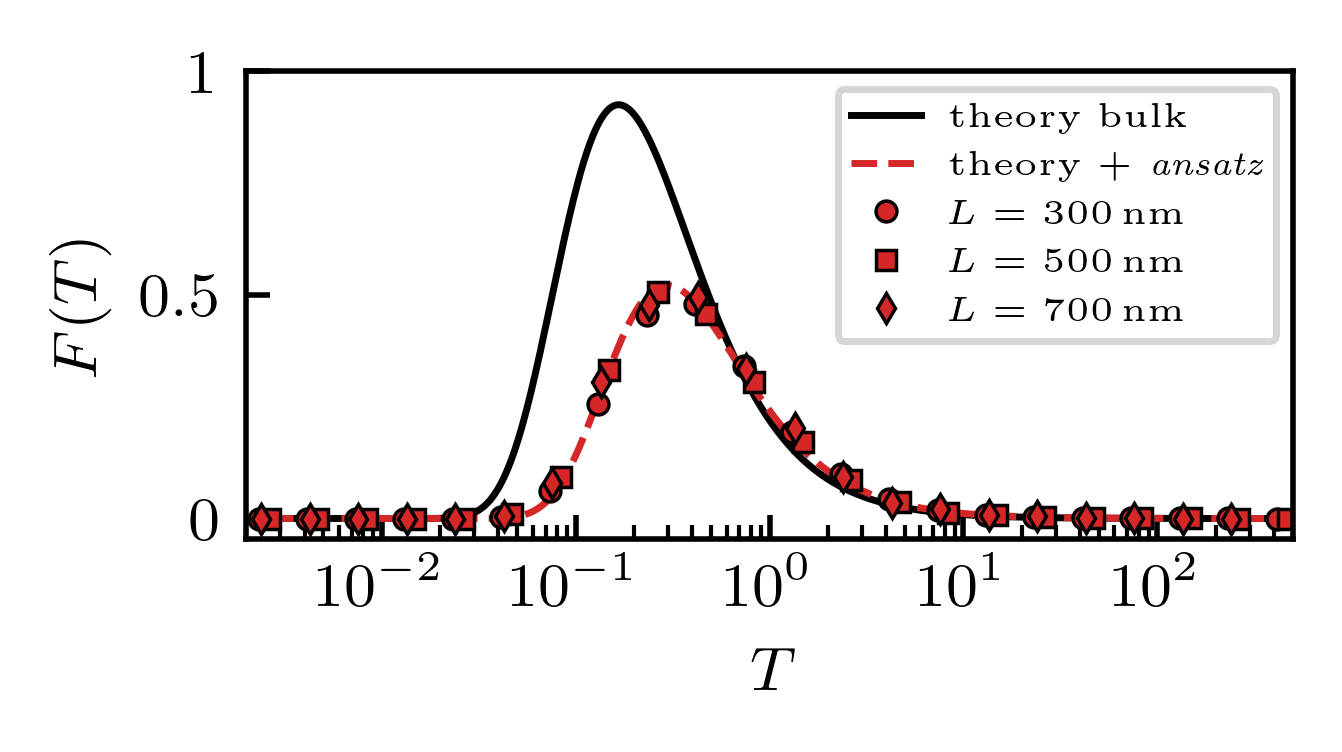

In [596]:
fig, ax = plt.subplots(1, 1, figsize=(7/2.54, 4/2.54))

ax.plot((bins_FPT_x_theory_L300nm*D0)/(L[0]**2), (hist_FPT_x_theory_L300nm*L[0]**2)/D0, '-k',lw = 1, label = 'theory bulk')
ax.plot((bins_FPT_x_theory_L300nm*D0)/(L[0]**2), (Levy(bins_FPT_x_theory_L300nm, L=L[0], D=meanDx_MSD)*L[0]**2)/D0, '--',lw = 1, color = 'tab:red', label=r'theory + $\textit{ansatz}$')
ax.semilogx((bins_FPT_x_L300nm*D0)/(L[0]**2), (hist_FPT_x_L300nm*L[0]**2)/D0, 'o', color = 'tab:red', ms = 3,  mew=0.5, label=r'$L=300 \, \mathrm{nm}$')

ax.semilogx((bins_FPT_x_L500nm*D0)/(L[1]**2), (hist_FPT_x_L500nm*L[1]**2)/D0, 's', color = 'tab:red', ms = 3,  mew=0.5, label=r'$L=500 \, \mathrm{nm}$')
#ax.plot((bins_FPT_x_theory_L500nm*D0)/(L[1]**2), (hist_FPT_x_theory_L500nm*L[1]**2)/D0, '-k', label = 'theory bulk')

ax.semilogx((bins_FPT_x_L700nm*D0)/(L[2]**2), (hist_FPT_x_L700nm*L[2]**2)/D0, 'd', color = 'tab:red', ms = 3,  mew=0.5, label=r'$L=700 \, \mathrm{nm}$')
#ax.plot((bins_FPT_x_theory_L800nm*D0)/(L[2]**2), (hist_FPT_x_theory_L800nm*L[2]**2)/D0, '-k', label = 'theory bulk')
#ax.plot((bins_FPT_x_theory_L800nm*D0)/(L[2]**2), (Levy(bins_FPT_x_theory_L800nm, L=L[2], D=meanDx_MSD)*L[0]**2)/D0, '--k', label=r'theory bulk + $\textit{ansatz}$')
#ax.plot(bins_FPT_x_theory, Levy(bins_FPT_x_theory, L=L[0], D=popt[0]), '--', c = 'tab:red', label = 'fit of $D$')
ax.set(xlabel=r'$T$', ylabel=r'$F(T)$')
#ax.annotate(
    #r"L = {} $\mu$m".format(np.round(Li * 1e6, 1)), 
    #xy=(0, 0),  xycoords='axes fraction', xytext=(0.7, 0.2), textcoords='axes fraction', color='k',  
    #horizontalalignment='right', verticalalignment='top', 
    #fontsize=9, 
#)
ax.set_yticks([0, 0.5, 1], [0, 0.5, 1])
ax.set_xlim(2e-3, 5e2)
ax.legend(fontsize = 5)
plt.tight_layout()
fig.savefig('/Users/guirecdetournemire/Desktop/PhD/data/2025/20251107-check_L-influence/fig_SM_Fx(T)_Ls.pdf', transparent = True)
plt.show()

In [188]:
popt[0]

np.float64(8.176604924873741e-14)

In [50]:
def delta_t_max(bins, hist_theory, hist_data):
    index_max_bulk = np.argmax(hist_theory)
    index_max_fit = np.argmax(hist_data)

    t_max_bulk = bins[index_max_bulk]
    t_max_fit = bins[index_max_fit]

    res = (t_max_fit - t_max_bulk) / t_max_bulk

    return res

In [51]:
delta_t = delta_t_max(bins_FPT_x_theory, hist_FPT_x_theory, Levy(bins_FPT_x_theory, L=500e-9, D=popt[0]))

In [52]:
delta_t

np.float64(1.7254325312810295)

In [53]:
save['D0'] = D0
save['meanDx_MSD'] = meanDx_MSD
save['bins_FPT_x'] = bins_FPT_x
save['hist_FPT_x'] = hist_FPT_x
save['bins_FPT_x_theory'] = bins_FPT_x_theory
save['hist_FPT_x_theory_bulk'] = hist_FPT_x_theory
save['hist_FPT_x_theory_confined'] = Levy(bins_FPT_x_theory, L=500e-9, D=meanDx)
save['delta_t'] = delta_t

In [54]:
#save_path = ''/Users/guirecdetournemire/Desktop/PhD/paper/First Passage Time/data_lB_scan/lB1528nm''
#savemat(save_path + r'/data_simu_lB1528nm_Lx0p5um_Lz0p3um.matt', save)

### along $z$

In [482]:
Lz = [300e-9, 400e-9, 500e-9]
z0 = 0

In [483]:
%%time

FPT_z_L150nm = get_FPT_numba(z, dt=dt, L=Lz[0])
FPT_z_L300nm = get_FPT_numba(z, dt=dt, L=Lz[1])
FPT_z_L450nm = get_FPT_numba(z, dt=dt, L=Lz[2])

CPU times: user 5min 14s, sys: 1.52 s, total: 5min 16s
Wall time: 5min 16s


In [504]:
bins_FPT_z_L150nm, _, hist_FPT_z_L150nm = co.logarithmic_hist(FPT_z_L150nm, begin=dt, stop=1000, num=37, base=10)
bins_FPT_z_L300nm, _, hist_FPT_z_L300nm = co.logarithmic_hist(FPT_z_L300nm, begin=dt, stop=1000, num=37, base=10)
bins_FPT_z_L450nm, _, hist_FPT_z_L450nm = co.logarithmic_hist(FPT_z_L450nm, begin=dt, stop=1000, num=37, base=10)

In [505]:
bins_FPT_z_theory_L150nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_z_L150nm)), 1000)
hist_FPT_z_theory_L150nm = Levy(bins_FPT_z_theory_L150nm, L=Lz[0], D=D0)

bins_FPT_z_theory_L300nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_z_L300nm)), 1000)
hist_FPT_z_theory_L300nm = Levy(bins_FPT_z_theory_L300nm, L=Lz[1], D=D0)

bins_FPT_z_theory_L450nm = np.logspace(np.log10(dt), np.log10(np.max(FPT_z_L450nm)), 1000)
hist_FPT_z_theory_L450nm = Levy(bins_FPT_z_theory_L450nm, L=Lz[2], D=D0)

In [506]:
#popt, _ = curve_fit(lambda t, D: Levy(t, L=Lz, D=D), bins_FPT_z, hist_FPT_z, p0=[meanDz])

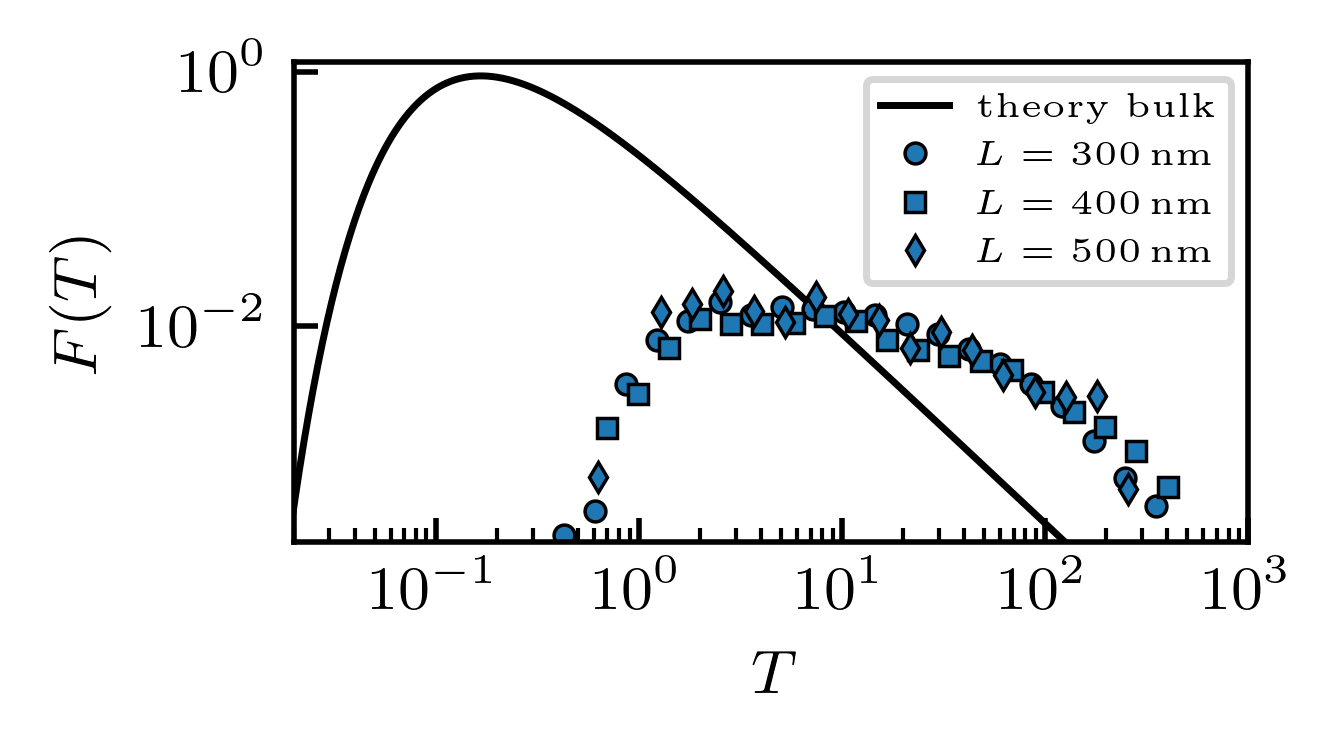

In [513]:
fig, ax = plt.subplots(1, 1, figsize=(7/2.54, 4/2.54))


ax.loglog((bins_FPT_z_theory_L150nm*D0)/(Lz[0]**2), (hist_FPT_z_theory_L150nm*Lz[0]**2)/D0, '-k', lw = 1,label = 'theory bulk')
#ax.loglog((bins_FPT_z_theory_L150nm*D0)/(Lz[0]**2), (Levy(bins_FPT_z_theory_L150nm, L = Lz[0], D = meanDz_MSD)*Lz[0]**2)/D0, '-', color = 'tab:blue', lw = 1,label = 'theory + ansatz')
ax.loglog((bins_FPT_z_L150nm*D0)/(Lz[0]**2), (hist_FPT_z_L150nm*Lz[0]**2)/D0, 'o', color = 'tab:blue', ms = 3,  mew=0.5, label=r'$L=300 \, \mathrm{nm}$')

ax.plot((bins_FPT_z_L300nm*D0)/(Lz[1]**2), (hist_FPT_z_L300nm*Lz[1]**2)/D0, 's', color = 'tab:blue', ms = 3,  mew=0.5, label=r'$L=400 \, \mathrm{nm}$')

ax.plot((bins_FPT_z_L450nm*D0)/(Lz[2]**2), (hist_FPT_z_L450nm*Lz[2]**2)/D0, 'd', color = 'tab:blue', ms = 3,  mew=0.5, label=r'$L=500 \, \mathrm{nm}$')

ax.set(xlabel=r'$T$', ylabel=r'$F(T)$')
#ax.annotate(
    #r"L = {} $\mu$m".format(np.round(Li * 1e6, 1)), 
    #xy=(0, 0),  xycoords='axes fraction', xytext=(0.7, 0.2), textcoords='axes fraction', color='k',  
    #horizontalalignment='right', verticalalignment='top', 
    #fontsize=9, 
#)
ax.set_xlim(2e-2, 1e3)
ax.set_ylim(2e-4, 1.2)

ax.legend(fontsize = 5, loc ='upper right', frameon = True)
plt.tight_layout()
fig.savefig('/Users/guirecdetournemire/Desktop/PhD/data/2025/20251107-check_L-influence/fig_SM_Fz(T)_Ls_a3um.pdf', transparent = True)
plt.show()

In [62]:
save['bins_FPT_z'] = bins_FPT_z
save['hist_FPT_z'] = hist_FPT_z
save['bins_FPT_z_theory'] = bins_FPT_z_theory
save['hist_FPT_z_theory_bulk'] = hist_FPT_z_theory_bulk
save['hist_FPT_z_theory_confined'] = Levy(bins_FPT_z_theory, L=Lz, D=meanDz)

In [66]:
save_path = '/Users/guirecdetournemire/Desktop/PhD/data/2025/20250908_simu_DeltaT(lB)/'
#savemat(save_path + 'data_simu_DeltaT_lB100_000nm.mat', save)

In [ ]:
# fig.savefig('P_tau.pdf')

# Several Trajectories

## Generate several trajectories

In [502]:
N_traj = 10
Nt = 100_000
dt_num = 1e-3
Nt_sub = 10
dt = dt_num * Nt_sub

print('Electrostatics and gravity: B = {0}, lD = {1} nm, and lB = {2} nm'.format(B, lD*1e9, lB*1e9))
print('Physical timestep = {} s'.format(dt))

Electrostatics and gravity: B = 9, lD = 35.0 nm, and lB = 170.0 nm
Physical timestep = 0.01 s


In [503]:
def compute_one_traj(i, dt, Nt, Nt_sub, a, H, lD, lB, B, eta0, T, R0=None):
    brown = DoubleWallsLangevin(
        dt=dt_num, Nt=Nt, Nt_sub=Nt_sub, 
        a=a, H=H, lD=lD, lB=lB, B=B, eta0=eta0, T=T, 
        R0=R0, 
    )
    brown.trajectory()
    x = brown.Xn
    z = brown.Zn + H
    return x, z

In [504]:
%%time 

params = [(i, dt_num, Nt, Nt_sub, a, H, lD, lB, B, eta0, T, None) for i in np.arange(N_traj)]
with Pool(30) as p:
    res = p.starmap(compute_one_traj, params)

Process SpawnPoolWorker-1:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-5:
Traceback (most recent call last):
  File "/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
AttributeError: Can't get attribute 'compute_one_traj' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "/Users/guirecdetournemire/miniconda3/envs/simulation/lib/python3.9/multiprocessing/process.p

KeyboardInterrupt: 

In [505]:
xs = np.zeros((Nt, N_traj))
zs = np.zeros((Nt, N_traj))
for j in range(N_traj):
    xs[:,j] = res[j][0]
    zs[:,j] = res[j][1]

NameError: name 'res' is not defined

In [ ]:
save['N_traj'] = N_traj
save['Nt'] = Nt
save['dt'] = dt
save['dt_num'] = dt_num
save['Nt_sub'] = Nt_sub

save['xs'] = np.copy(xs)
save['zs'] = np.copy(zs)

## Look at trajectories and observables

In [ ]:
def measure_Peq(zs, min_distance, max_distance, n_bins, base=2):
    N_traj = zs.shape[1]
    all_x_P_eq, all_width_P_eq, all_y_P_eq = np.zeros((N_traj, n_bins)), np.zeros((N_traj, n_bins)), np.zeros((N_traj, n_bins))
    # Histogram over all the positions z
    for p in range(N_traj):
        z_temp = zs[:,p]
        z_temp = z_temp[~np.isnan(z_temp)]
        x_P_eq_temp, width_P_eq_temp, y_P_eq_temp = logarithmic_hist(zs[:,p], min_distance, max_distance, num=n_bins+1, base=base, density=True)
        all_x_P_eq[p,:] = np.copy(x_P_eq_temp)
        all_width_P_eq[p,:] = np.copy(width_P_eq_temp)
        all_y_P_eq[p,:] = np.copy(y_P_eq_temp)
    x_P_eq = np.nanmean(all_x_P_eq, axis=0)
    width_P_eq = np.nanmean(all_width_P_eq, axis=0)
    y_P_eq = np.nanmean(all_y_P_eq, axis=0)
    del all_x_P_eq, all_width_P_eq, all_y_P_eq
    return x_P_eq, width_P_eq, y_P_eq

In [ ]:
min_distance = 20e-9 
max_distance = 0.8e-6
n_bins = 20

In [ ]:
%%time 
x_P_eq, width_P_eq, y_P_eq = measure_Peq(zs[:,:], min_distance, max_distance, n_bins, base=10)

# y_P_eq = y_P_eq / np.trapezoid(y_P_eq, x_P_eq)

In [ ]:
delta_frame_nb = np.concatenate(
    (
        np.arange(1, 10, 1),
        np.arange(10, 100, 10),
        np.arange(100, 1000, 100),
        np.arange(1000, 10000, 1000),
        np.arange(10000, 50000, 10000), 
    )
)

delta_time_MSD = delta_frame_nb * dt

In [ ]:
from math import sqrt

def moment(n, xs, delta_frame_nb, return_err=False, retrieve_mean=False):
    res = np.zeros_like(delta_frame_nb) * np.nan
    err = np.zeros_like(res) * np.nan
    N_traj = np.shape(xs)[1]
    for i, df in enumerate(delta_frame_nb):
        dxs = xs[df:,:] - xs[:-df,:]
        if retrieve_mean:
            for p in range(N_traj):
                dxs[:,p] = dxs[:,p] - np.nanmean(dxs[:,p])
        dxs_n = dxs ** n 
        res[i] = np.nanmean(dxs_n)
        err[i] = np.nanstd(dxs_n) / sqrt(dxs_n.size)
    if return_err:
        return res, err
    return res

def measure_MSD(xs, delta_frame_nb, return_err=False, retrieve_mean=False):
    return moment(2, xs, delta_frame_nb, return_err=return_err, retrieve_mean=retrieve_mean)

# @njit
# def moment_numba(n, xs, delta_frame_nb):
#     res = np.empty_like(delta_frame_nb, dtype=np.float64)
#     err = np.empty_like(res)
#     N_t, N_traj = np.shape(xs)
#     for i in range(len(delta_frame_nb)):
#         df = delta_frame_nb[i]
#         if df <= 0 or df >= N_t:
#             res[i] = np.nan
#             continue
#         count = N_t - df
#         acc = 0.0
#         std = np.empty(N_traj+count, dtype=np.float64)
#         for j in range(N_traj):
#             for k in range(count):
#                 dx_n = (xs[k+df, j] - xs[k, j]) ** n
#                 acc += dx_n
#                 std
#         std = np.array(std)
#         res[i] = acc / (count * N_traj)
#     return res, err

# def measure_MSD_numba(xs, delta_frame_nb):
#     return moment_numba(2, xs, delta_frame_nb)

In [ ]:
%%time 

MSD_x, std_MSD_x = measure_MSD(xs, delta_frame_nb, return_err=True)
MSD_z, std_MSD_z = measure_MSD(zs, delta_frame_nb, return_err=True)

In [ ]:
D0 = kT / (6*np.pi*eta0*a)

start = 0
stop = 10
coef_MSD_x = np.polyfit(delta_time_MSD[start:stop], MSD_x[start:stop], 1)
coef_MSD_z = np.polyfit(delta_time_MSD[start:stop], MSD_z[start:stop], 1)
meanDx_MSD = coef_MSD_x[0] / 2
meanDz_MSD = coef_MSD_z[0] / 2

In [ ]:
zz = np.linspace(1e-9, 10e-6, int(1e6))

meanDx = np.trapezoid(P_eq(zz, B, lD, lB) * diffusing_diffusivity_x(zz, a), zz) * D0
meanDz = np.trapezoid(P_eq(zz, B, lD, lB) * diffusing_diffusivity_z(zz, a), zz) * D0

def _P_dz_long(dz, B, lD, lB, zz=zz):
    return np.trapezoid(P_eq(zz, B, lD, lB, normalize=False) * P_eq(zz + dz, B, lD, lB, normalize=False), zz)
def P_dz_long(dzz, B, lD, lB, zz=zz):
    res = np.zeros_like(dzz)
    for i in range(len(res)):
        res[i] = _P_dz_long(dzz[i], B, lD, lB, zz=zz)
    res = res / np.trapezoid(res, dzz)
    return res
    
dzz = np.linspace(-10e-6, 10e-6, int(1e3))

plateau_MSDz = np.trapezoid(dzz ** 2 * P_dz_long(dzz, B, lD, lB), dzz)

In [ ]:
# Plot 

x_P_eq_theory = np.linspace(min_distance, max_distance, int(1e6))
y_P_eq_theory = P_eq(x_P_eq_theory, B, lD, lB, normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(15/2.54, 6/2.54))

axes[0].plot(delta_time_MSD, MSD_x*1e12, 'o', mfc='tab:red', label=r'$x$')
axes[0].plot(delta_time_MSD, MSD_z*1e12, 'o', mfc='tab:blue', label=r'$z$')
axes[0].plot(delta_time_MSD, 2 * meanDx * delta_time_MSD * 1e12, ls='-', c='k', label=r'Theory $x$')
axes[0].plot(delta_time_MSD, 2 * meanDz * delta_time_MSD * 1e12, ls='--', c='k', label=r'Theory $z$')
dtime_MSD_long = delta_time_MSD[delta_time_MSD > 0.5]
axes[0].plot(dtime_MSD_long, np.ones_like(dtime_MSD_long) * plateau_MSDz * 1e12, ls='--', c='k')
axes[0].legend(frameon=True, handletextpad=0.5, handlelength=1.5, ncol=2, columnspacing=0.5, prop={'size': 8})
axes[0].set(xlabel='Time (s)', ylabel=r'MSD $(\mathrm{\mu m ^2})$', xscale='log', yscale='log')
axes[1].plot(x_P_eq*1e6, y_P_eq*1e-6, 'o', mfc='tab:blue')

# for p in range(N_traj):
#     x_P_eq_temp, width_P_eq_temp, y_P_eq_temp = measure_Peq(zs[:,p:p+1], min_distance, max_distance, n_bins, base=10)
#     axes[1].plot(x_P_eq_temp*1e6, y_P_eq_temp*1e-6, ls='-', c='gray', linewidth=0.3)
    
axes[1].plot(x_P_eq_theory*1e6, y_P_eq_theory*1e-6, ls='-', c='k')
axes[1].set(xlabel=r'$z \, \mathrm{(\mu m)}$', ylabel=r'$P_\mathrm{eq}(z) \, \mathrm{(\mu m ^{-1})}$', xscale='linear', yscale='log')

plt.tight_layout(pad=0.2)
plt.show()

In [ ]:
# fig.savefig('MSD_Peq.pdf', transparent=True)

## First-Passage Times

In [ ]:
@njit
def get_FPT_one_particle(x, l):
    Ntot = len(x)
    res = []
    for i in range(Ntot):
        x0 = x[i]
        j = i
        c = 0
        while x[j] < x0 + l:
            j += 1
            c += 1
            if j >= Ntot:
                c = np.nan
                break
        res.append(c)
        # Maybe: add a condition to break the loop if several FPTs in a row are nans
    res = np.array(res)
    res = res * dt
    return res

# @njit
def get_FPT_several_particles(xs, Ls):
    res = []
    N_traj = np.shape(xs)[1]
    for k in range(len(Ls)):
        l = Ls[k]
        fpt_temp = np.zeros_like(xs) * np.nan
        for p in tqdm(range(N_traj)):
            fpt_one_p = get_FPT_one_particle(xs[:,p], l)
            fpt_temp[:len(fpt_one_p),p] = fpt_one_p
        res.append(fpt_temp)
        print("L = {} um done.".format(np.round(l*1e6,2)))
    return res

In [ ]:
Ls = [300e-9]

In [ ]:
%%time

FPT_x = get_FPT_several_particles(xs, Ls)

In [ ]:
save['Ls'] = copy.deepcopy(Ls)
save['FPT_x'] = copy.deepcopy(FPT_x)

In [ ]:
k = 0

fpt_x = FPT_x[k][~np.isnan(FPT_x[k])]

print(np.shape(fpt_x))

bins_FPT_x, _, hist_FPT_x = co.logarithmic_hist(fpt_x, begin=np.min(fpt_x), stop=np.max(fpt_x), num=20, base=10, )

bins_FPT_x_theory = np.logspace(np.log10(np.min(bins_FPT_x)), np.log10(np.max(bins_FPT_x)), 1000)
hist_FPT_x_theory = Levy(bins_FPT_x_theory, L=Ls[k], D=meanDx)

popt, _ = curve_fit(lambda t, D: np.log10(Levy(t, L=Ls[k], D=D)), bins_FPT_x, np.log10(hist_FPT_x), p0=[meanDx]) # /!\ log fit
hist_FPT_x_fit = Levy(bins_FPT_x_theory, L=Ls[k], D=popt[0])

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15/2.54, 7/2.54))
ax.loglog(bins_FPT_x, hist_FPT_x, 'o')
ax.plot(bins_FPT_x_theory, hist_FPT_x_theory, '--', c='tab:red', label=r'Theory', zorder=3)
ax.plot(bins_FPT_x_theory, hist_FPT_x_fit, '--k', label='Fit')
ax.plot(bins_FPT_x_theory, Levy(bins_FPT_x_theory, L=Ls[k], D=meanDx_MSD), '-k', label='MSD')
ax.set(xlabel=r'$\tau \, \mathrm{(s)}$', ylabel=r'$P(\tau) \, \mathrm{(s^{-1})}$')
ax.legend()
ax.annotate(
    r"L = {} $\mu$m".format(np.round(Ls[k] * 1e6, 1)), 
    xy=(0, 0),  xycoords='axes fraction', xytext=(0.7, 0.4), textcoords='axes fraction', color='k',  
    horizontalalignment='right', verticalalignment='top', 
    fontsize=9, 
)
plt.tight_layout()
plt.show()

In [ ]:
# fig.savefig('FPT_P_tau.pdf')

In [ ]:
# savemat('simu_rigid_like_trajs_AR1000_in_water_20250624.mat', save)

# Compute N >> Trajectories and Analyze

Code to compute a huge nb of trajectories, save them individually in a folder. Later analyze all the trajectories, but not loading all of them at the same time. 

The analysis part needs to be coded.

In [24]:
def compute_one_traj(i, dt, Nt, Nt_sub, a, H, lD, lB, B, eta0, T, R0=None, folder='./test/'):
    brown = DoubleWallsLangevin(
        dt=dt_num, Nt=Nt, Nt_sub=Nt_sub, 
        a=a, H=H, lD=lD, lB=lB, B=B, eta0=eta0, T=T, 
        R0=R0, 
    )
    brown.trajectory()
    x = brown.Xn
    z = brown.Zn + H
    res = {'x': x, 'z': z}
    savemat(folder + 'traj_{}.mat'.format(i), res)
    # return x, z

In [25]:
%%time 

params = [(i, dt_num, Nt, Nt_sub, a, H, lD, lB, B, eta0, T, None) for i in np.arange(N_traj)]
with Pool(30) as p:
    _ = p.starmap(compute_one_traj, params)

CPU times: user 8.88 ms, sys: 134 ms, total: 143 ms
Wall time: 11 s
